In [ ]:
import pandas as pd
import kagglehub
path = kagglehub.dataset_download("jackwin07/celiac-disease-coeliac-disease")
df = pd.read_csv(path+"/celiac_disease_lab_data.csv")
df.head()

Using Colab cache for faster access to the 'celiac-disease-coeliac-disease' dataset.


,Age,Gender,Diabetes,Diabetes Type,Diarrhoea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,Yes,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,marsh type 0,potential,yes
1,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,marsh type 3a,atypical,yes
2,8,Female,Yes,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,marsh type 1,latent,yes
3,10,Male,Yes,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,marsh type 3a,silent,yes
4,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,marsh type 1,latent,yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2206 entries, 0 to 2205
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2206 non-null   int64  
 1   Gender            2206 non-null   object 
 2   Diabetes          2206 non-null   object 
 3   Diabetes Type     1788 non-null   object 
 4   Diarrhoea         2206 non-null   object 
 5   Abdominal         2206 non-null   object 
 6   Short_Stature     2206 non-null   object 
 7   Sticky_Stool      2206 non-null   object 
 8   Weight_loss       2206 non-null   object 
 9   IgA               2206 non-null   float64
 10  IgG               2206 non-null   float64
 11  IgM               2206 non-null   float64
 12  Marsh             2206 non-null   object 
 13  cd_type           2206 non-null   object 
 14  Disease_Diagnose  2206 non-null   object 
dtypes: float64(3), int64(1), object(11)
memory usage: 258.6+ KB


In [ ]:
df.describe()

,Age,IgA,IgG,IgM
count,2206.000000,2206.000000,2206.000000,2206.000000
mean,12.768812,1.427384,10.052901,1.236963
std,7.434250,1.110042,2.047683,0.447216
min,1.000000,0.340000,5.000000,0.500000
25%,8.000000,1.000000,8.700000,0.980000
50%,10.000000,1.100000,10.000000,1.100000
75%,15.000000,1.800000,12.000000,1.500000
max,35.000000,9.000000,15.300000,2.700000


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Diabetes,0
Diabetes Type,418
Diarrhoea,0
Abdominal,0
Short_Stature,0
Sticky_Stool,0
Weight_loss,0
IgA,0


**Visualization (EDA)**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


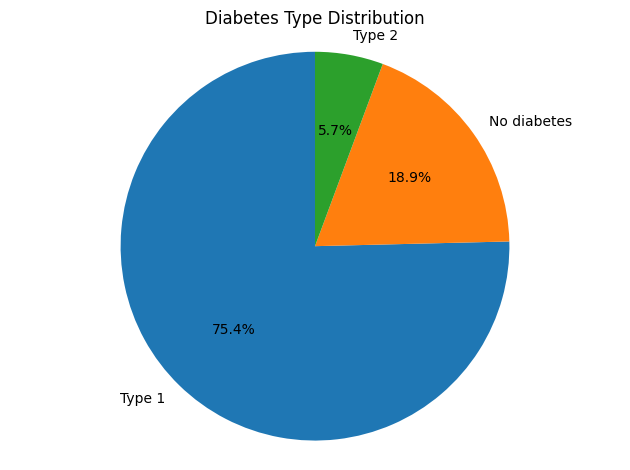

In [ ]:
# Fill missing values for plotting
df['Diabetes Type'] = df['Diabetes Type'].fillna('No diabetes')

# Create a pie chart for Diabetes Type distribution
df['Diabetes Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Diabetes Type Distribution")
plt.ylabel('') # Hide the default 'count' label for pie chart
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

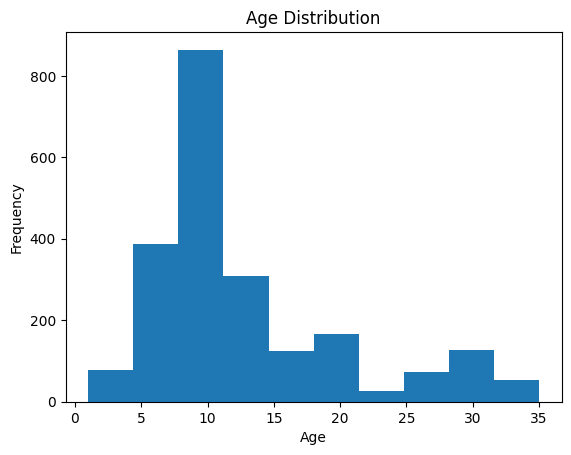

In [ ]:
# Age distribution
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

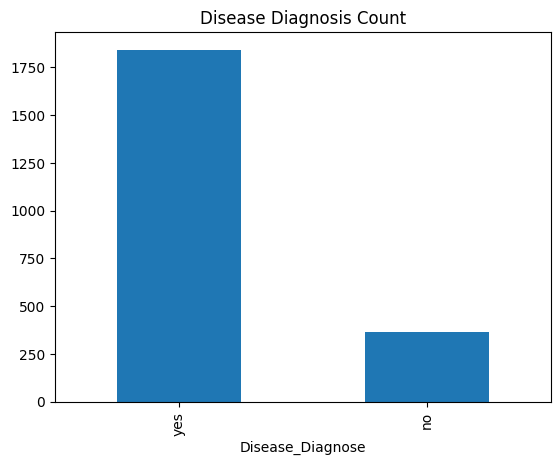

In [ ]:
# Disease count
df['Disease_Diagnose'].value_counts().plot(kind='bar')
plt.title("Disease Diagnosis Count")
plt.show()

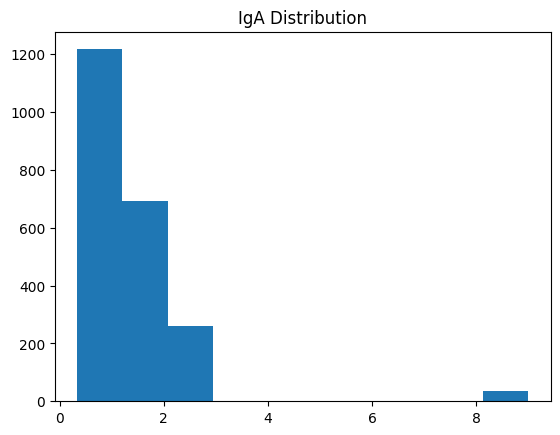

In [ ]:
# IgA distribution
plt.hist(df['IgA'])
plt.title("IgA Distribution")
plt.show()

**Data Preprocessing**

In [ ]:
from sklearn.preprocessing import LabelEncoder
df_clean = df.copy()

In [ ]:
# Fill missing values
df_clean['Diabetes Type'] = df_clean['Diabetes Type'].fillna("Unknown")

In [ ]:
# Encode categorical columns
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

In [ ]:
df_clean.head()

,Age,Gender,Diabetes,Diabetes Type,Diarrhoea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,1,0,1,1,1,1,0,0,1.30,10.0,1.00,0,3,1
1,9,1,0,1,0,1,1,0,0,1.50,12.5,1.30,3,0,1
2,8,0,0,1,2,1,2,1,1,0.40,8.0,0.50,1,1,1
3,10,1,0,1,2,1,1,0,0,0.98,9.0,0.66,3,4,1
4,9,1,0,1,0,1,1,0,0,1.00,10.5,1.10,1,1,1


**Train Model**

In [ ]:
from sklearn.model_selection import train_test_split
X = df_clean.drop(["Disease_Diagnose", "Marsh", "cd_type"], axis=1)
y = df_clean["Disease_Diagnose"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

**Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9728506787330317

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91        69
           1       0.98      0.99      0.98       373

    accuracy                           0.97       442
   macro avg       0.96      0.93      0.95       442
weighted avg       0.97      0.97      0.97       442



In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9592760180995475

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.84      0.87        69
           1       0.97      0.98      0.98       373

    accuracy                           0.96       442
   macro avg       0.93      0.91      0.92       442
weighted avg       0.96      0.96      0.96       442



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

**Training Multiple Models**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.959276,0.970822,0.981233,0.976000
1,Decision Tree,0.961538,0.973404,0.981233,0.977303
2,Random Forest,0.972851,0.976253,0.991957,0.984043
3,SVM,0.961538,0.973404,0.981233,0.977303


**Plotting for Model Comparison**

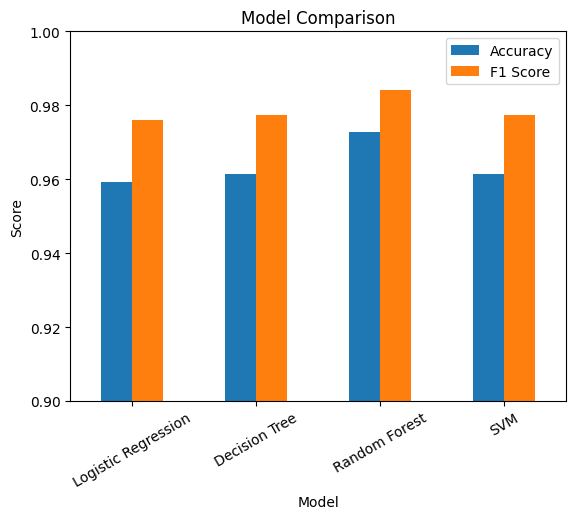

In [ ]:
results_df.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0.9, 1.0)
plt.show()

**Hyperparameter Tuning**

1. *Decision Tree Tuning*

In [ ]:
dt_params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5)
dt_grid.fit(X_train, y_train)

print("Best Decision Tree:", dt_grid.best_params_)

Best Decision Tree: {'max_depth': 5, 'min_samples_split': 2}


2. *Random Forest Tuning*

In [ ]:
rf_params = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=5)
rf_grid.fit(X_train, y_train)

print("Best Random Forest:", rf_grid.best_params_)

Best Random Forest: {'max_depth': 5, 'n_estimators': 100}


3. *SVM Tuning*

In [ ]:
svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(SVC(), svm_params, cv=5)
svm_grid.fit(X_train, y_train)

print("Best SVM:", svm_grid.best_params_)

Best SVM: {'C': 1, 'kernel': 'rbf'}


**Comparison of Tuned Models**

In [ ]:
tuned_models = {
    "Decision Tree Tuned": dt_grid.best_estimator_,
    "Random Forest Tuned": rf_grid.best_estimator_,
    "SVM Tuned": svm_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

tuned_df = pd.DataFrame(tuned_results)
tuned_df

,Model,Accuracy,F1 Score
0,Decision Tree Tuned,0.975113,0.985430
1,Random Forest Tuned,0.979638,0.988079
2,SVM Tuned,0.961538,0.977303


**Final Comparison Plot**

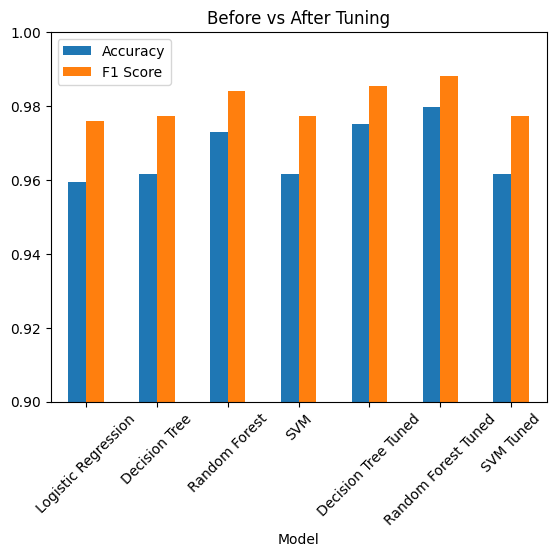

In [ ]:
combined = pd.concat([results_df, tuned_df], ignore_index=True)

combined.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind='bar')
plt.title("Before vs After Tuning")
plt.xticks(rotation=45)
plt.ylim(0.9, 1.0) # Set y-axis limit to clearly see differences
plt.show()

### Combine Data, Retrain Best Model, and Export

In [ ]:
# Combine X_train and X_test, and y_train and y_test
X_combined = pd.concat([X_train, X_test], ignore_index=True)
y_combined = pd.concat([y_train, y_test], ignore_index=True)

print("Combined X shape:", X_combined.shape)
print("Combined y shape:", y_combined.shape)


Combined X shape: (2206, 12)
Combined y shape: (2206,)


In [ ]:
# The best model based on previous tuning was RandomForestClassifier with max_depth=5, n_estimators=100
best_model = rf_grid.best_estimator_

# Retrain the best model on the combined dataset
best_model.fit(X_combined, y_combined)

print("Best model (Random Forest) retrained on combined data.")


Best model (Random Forest) retrained on combined data.


### Export Model

In [ ]:
import pickle
from google.colab import files

# Save the retrained best model
model_filename = "celiac_model.pkl"
with open(model_filename, "wb") as f:
    pickle.dump(best_model, f)

print(f"Model saved successfully as {model_filename}!")

# Download the file
files.download(model_filename)


Model saved successfully as celiac_model_tuned_rf.pkl!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>